# TP3 - Détection et Traitement des Outliers

**Difficulté:** Intermédiaire  
**Dataset:** sales_outliers.csv  
**Description:** Identification des valeurs aberrantes avec méthodes statistiques

---


## Imports des Bibliothèques


In [1]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
from ydata_profiling import ProfileReport

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")

 Bibliothèques importées avec succès!


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_6244\447647162.py:8: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


## Import du Dataset


In [2]:
# Charger le dataset
df = pd.read_csv('data/sales_outliers.csv')

# Afficher les informations de base
print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f" Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()

📏 Dimensions: 1020 lignes × 4 colonnes
 Taille mémoire: 0.12 MB




,transaction_id,amount,product,date
0,1,1458.56,B,2023-01-01
1,2,4399.43,B,2023-01-02
2,3,1298.67,C,2023-01-03
3,4,1580.76,A,2023-01-04
4,5,946.03,C,2023-01-05




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  1020 non-null   int64  
 1   amount          1020 non-null   float64
 2   product         1020 non-null   object 
 3   date            1020 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 32.0+ KB


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

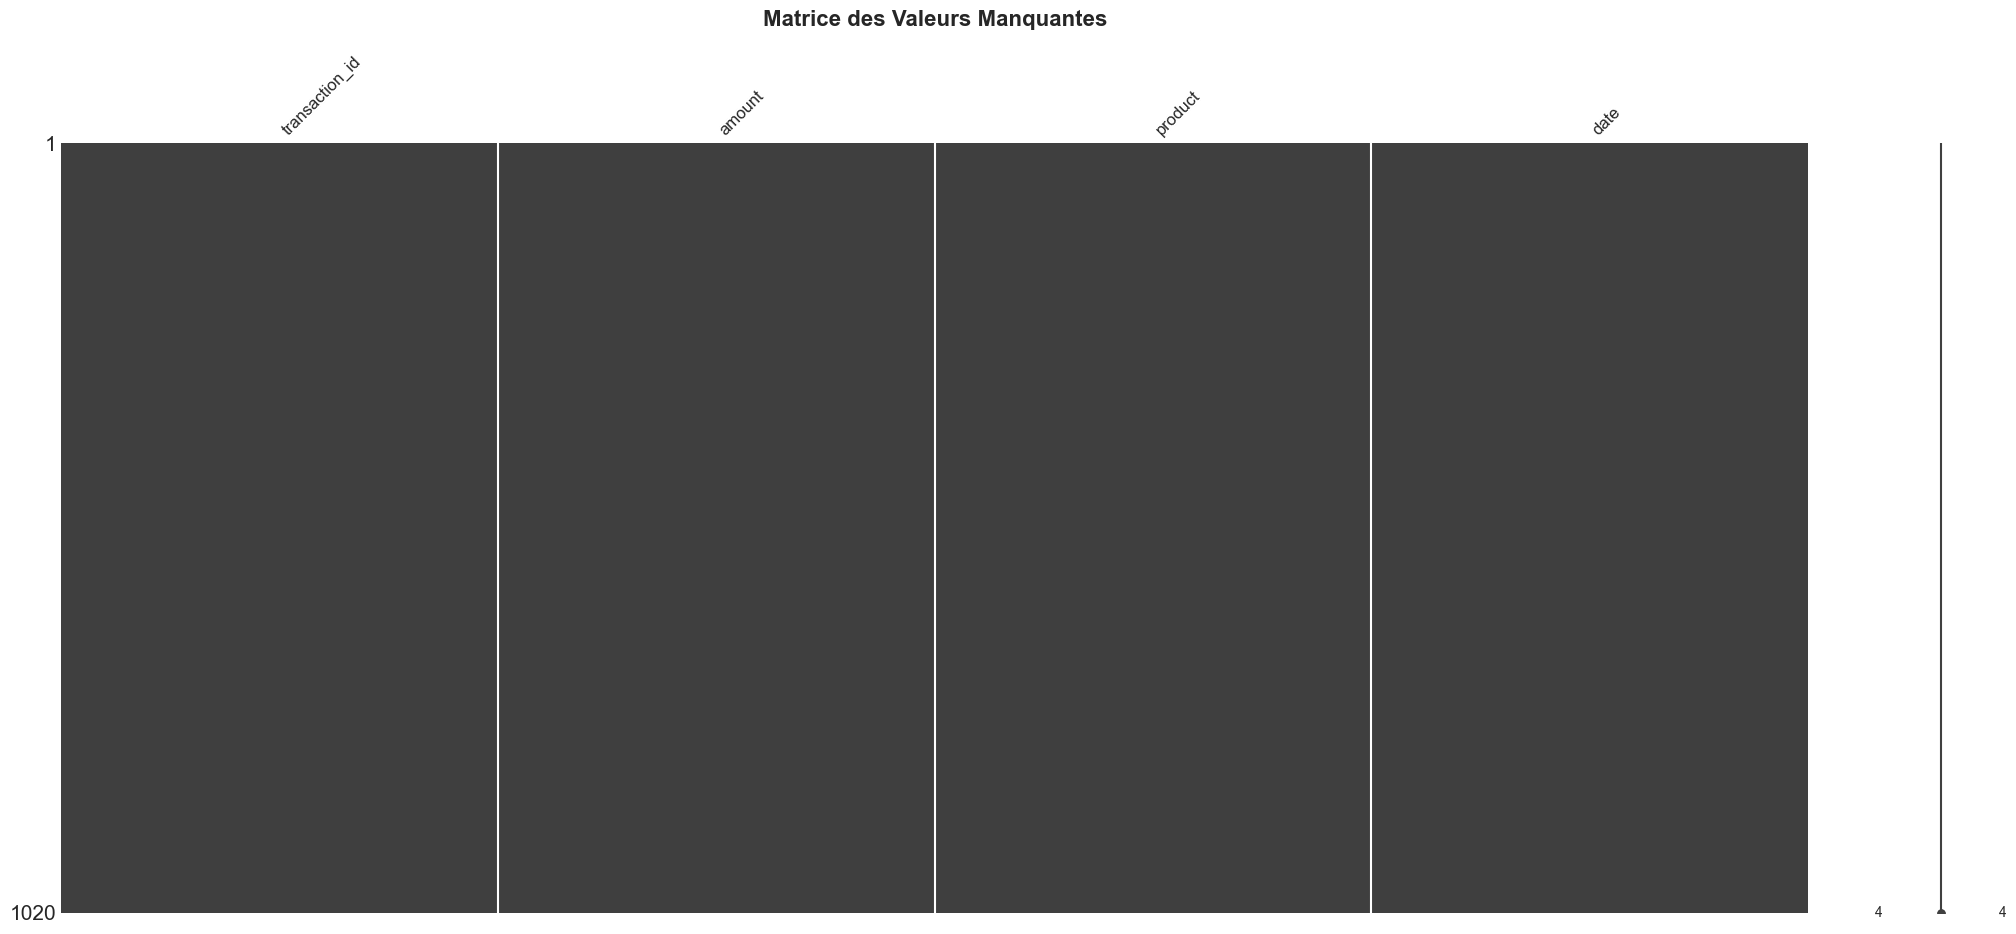


📊 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing


In [3]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n📊 Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])


## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Quelle est la distribution de la colonne 'amount' ?
2. Y a-t-il des valeurs négatives dans les montants ?
3. Quel est le montant maximum et semble-t-il aberrant ?
4. Combien d'outliers détecte la méthode IQR pour 'amount' ?
5. Combien d'outliers détecte la méthode Z-score (threshold=3) ?
6. Les deux méthodes identifient-elles les mêmes outliers ?
7. Quelle proportion du dataset représentent les outliers ?
8. Y a-t-il une corrélation entre outliers et une catégorie spécifique ?
9. Les outliers sont-ils des erreurs ou des valeurs légitimes ?
10. Comment la moyenne change-t-elle après traitement des outliers ?


In [4]:
# Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions

# Exemple d'analyses:
# df.describe()
# df['colonne'].value_counts()
# df.isnull().sum()
# etc.

print("Réponses aux questions:")
print("="*80)

# Écrivez vos réponses ici

print("-"*80)
print("1. Distribution de la colonne amount")
display(df['amount'].describe())

print("-"*80)
print("2. Nombre de valeurs négative dans amount ?")
print(df.query('amount < 0')['amount'].count()) # Aucunes valeurs négatives

print("-"*80)
print("3. Montant maximum ?")
print(df['amount'].max())
# 185913.06 peut paraitre abhérent vu que la majorité des valeurs (841) se tient en dessous des 10000, 
# mais ne sachant pas trop ce qui est vendu  ni le contexte, il est difficile de dire si c'est plus abhérent que les autres valeurs
# si je devait mettre un cut, je le mettrais à 20000, car 98 valeurs sont comprises entre 10k et 20k ce aui représente presque 10% des données

print("-"*80)
print("4. Oulier sur 'amount', méthode IQR")

# Détection par IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25) # Calcul du premier quartile
    Q3 = df[column].quantile(0.75) # Calcul du troisième quartile
    IQR = Q3 - Q1 # Calcul de l'intervalle interquartile
    lower_bound = Q1 - 1.5 * IQR # Calcul de la borne inférieure, peut donner une valeur négative
    upper_bound = Q3 + 1.5 * IQR # Calcul de la borne supérieure
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    # Retourne les valeurs aberrantes (celles au dela des bornes), la borne inférieure et la borne supérieure
    return outliers, lower_bound, upper_bound

outliers_iqr, lower_iqr, upper_iqr = detect_outliers_iqr(df, 'amount')
print(f"Nombre d'outliers: {len(outliers_iqr)}")
print(f"Limites: [{lower_iqr:.2f}, {upper_iqr:.2f}]")

print("-"*80)
print("5. Outliers sur 'amount', méthode Z-score")

#  Limitation : Assume une distribution normale. Moins efficace pour des distributions asymétriques. 
def detect_outliers_zscore(df, column):
    # Calcul du Z-score (necessite l'import suivant : from scipy import stats)
    z_scores = np.abs(stats.zscore(df[column]))
    threshold = 3
    # Détection des outliers
    outliers = df[z_scores > threshold]
    return outliers

outliers_zscore = detect_outliers_zscore(df, 'amount')

print(f"Nombre d'outliers: {len(outliers_zscore)}")

print("-"*80)
print("6. Comparaison des résultats des deux méthodes")
reponse = """
# Les deux resultats sont très différents, la méthode IQR nous donne 105 valeurs abhérentes, tandis que le zscore plus que 22; presque le cinquieme.
# Le z-score étant une méthode de variation par rapport a la moyenne, il n'est pas des plus adaptée a des données de ventes qui n'ont pas de lien statistiques cohérents entre eux
"""
print(reponse)

print("-"*80)
print("7. Quelle proportion du dataset est concernée par les outliers ?")

print("Vérification des outliers sur toute colonne numerique du dataset")
for col in df.select_dtypes(include=['number']).columns:
    len_ds = len(df)
    oiqr, l, u = detect_outliers_iqr(df, col)
    oz = detect_outliers_zscore(df, col)
    print(f"Proportion des outliers dans {col} par rapport au dataset (Z-Score): {len(oiqr)/len_ds:.2%}")
    print(f"Proportion des outliers dans {col} par rapport au dataset (IQR): {len(oz)/len_ds:.2%}")

print("-"*80)
print("8. Corrélation entre outliers et une catégorie spécifique ?")
reponse = """
Dans ce dataset, la seule colonne numerique qui est touché par des outliers est le amount, 
et il n'y a pas de colonne categorique qui pourrait être corrélé avec celle-ci.
D'autant plus que les données brutes du ds avec trois produits A, B et C aux prix très différents ne nous pousse pas a y voir une quelconque logique.
"""
print(reponse)

print("-"*80)
print("9. Outliers; erreurs ou vraies valeures ?")
reponse = """
En prennant en compte les remarques émises plus haut, il est difficile de statuer sur la nature des outliers que l'ont a détecté.
Ils peuvent tout a la foit etre le fruit d'une erreur d'entrée tout comme des valeures légitime.
Il nous manque du contexte pour trancher la question.
"""
print(reponse)

print("-"*80)
print("10. Effet sur la moyenne de la suppression des outliers")

moy_base = df['amount'].mean()
print(f"Moyenne dea amount avant suppression des outliers: {moy_base:.2f}")

print("Cas 1 - suppression des outliers par méthode IQR")
df_iqr = df.drop(outliers_iqr.index)
moy_iqr = df_iqr['amount'].mean()
print(f"Moyenne dea amount après suppression des outliers: {moy_iqr:.2f}")
print(f"Pourcentage de baisse : {1-(moy_iqr / moy_base):.2%}")

print("Cas 2 - suppression des outliers par méthode Z-Score")
df_z = df.drop(outliers_zscore.index)
moy_z = df_z['amount'].mean()
print(f"Moyenne dea amount après suppression des outliers: {moy_z:.2f}")
print(f"Pourcentage de baisse : {1-(moy_z / moy_base):.2%}")

reponse = """
Dans les deux cas la moyenne est fortement impactée vers le bas
"""
print(reponse)

Réponses aux questions:
--------------------------------------------------------------------------------
1. Distribution de la colonne amount


count     1020.00
mean      8616.96
std      20525.04
min         79.57
25%       1441.20
50%       3152.76
75%       7221.39
max     185913.06
Name: amount, dtype: float64

--------------------------------------------------------------------------------
2. Nombre de valeurs négative dans amount ?
0
--------------------------------------------------------------------------------
3. Montant maximum ?
185913.06
--------------------------------------------------------------------------------
4. Oulier sur 'amount', méthode IQR
Nombre d'outliers: 105
Limites: [-7229.09, 15891.68]
--------------------------------------------------------------------------------
5. Outliers sur 'amount', méthode Z-score
Nombre d'outliers: 22
--------------------------------------------------------------------------------
6. Comparaison des résultats des deux méthodes

# Les deux resultats sont très différents, la méthode IQR nous donne 105 valeurs abhérentes, tandis que le zscore plus que 22; presque le cinquieme.
# Le z-score étant une méthode de variation par rapport a la moyenne, il n'est pas des plus adaptée a des données de ventes qui n'ont pas de lien statistiques cohérents

## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Visualiser la distribution avec boxplot et histogramme
### Étape 2: Calculer les statistiques descriptives
### Étape 3: Implémenter la détection par méthode IQR
### Étape 4: Implémenter la détection par Z-score
### Étape 5: Comparer les résultats des deux méthodes
### Étape 6: Décider d'une stratégie: suppression ou capping
### Étape 7: Appliquer le capping (Winsorization) aux valeurs extrêmes
### Étape 8: Visualiser la distribution avant/après traitement
### Étape 9: Calculer l'impact sur les statistiques (moyenne, écart-type)
### Étape 10: Documenter les outliers traités dans un rapport


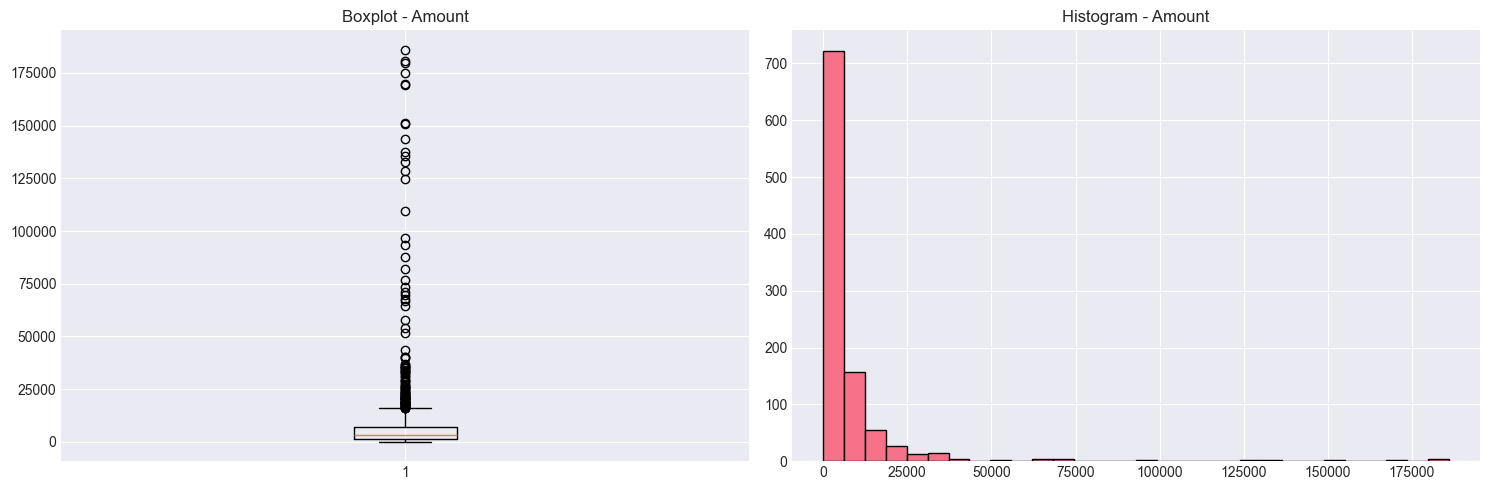

 Étape 1 complétée


In [5]:
# ========================================
# Étape 1: Visualiser la distribution avec boxplot et histogramme
# ========================================

# Permet d'avoir plusieurs graphiques sur la meme ligne
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot (Graphique qui sera le premier sur l'axe)
axes[0].boxplot(df['amount'])
axes[0].set_title('Boxplot - Amount')

# Histogram (Graphique qui sera le second sur l'axe)
axes[1].hist(df['amount'], bins=30, edgecolor='black')
axes[1].set_title('Histogram - Amount')

plt.tight_layout()
plt.show()

# Vérification
print(f" Étape 1 complétée")

In [6]:
# ========================================
# Étape 2: Calculer les statistiques descriptives
# ========================================

display(df['amount'].describe())


# Vérification
print(f" Étape 2 complétée")

count     1020.00
mean      8616.96
std      20525.04
min         79.57
25%       1441.20
50%       3152.76
75%       7221.39
max     185913.06
Name: amount, dtype: float64

 Étape 2 complétée


In [7]:
# ========================================
# Étape 3: Implémenter la détection par méthode IQR
# ========================================

# Détection par IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25) # Calcul du premier quartile
    Q3 = df[column].quantile(0.75) # Calcul du troisième quartile
    IQR = Q3 - Q1 # Calcul de l'intervalle interquartile
    lower_bound = Q1 - 1.5 * IQR # Calcul de la borne inférieure, peut donner une valeur négative
    upper_bound = Q3 + 1.5 * IQR # Calcul de la borne supérieure
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    # Retourne les valeurs aberrantes (celles au dela des bornes), la borne inférieure et la borne supérieure
    return outliers, lower_bound, upper_bound

outliers_iqr, lower_iqr, upper_iqr = detect_outliers_iqr(df, 'amount')

print(f"Nombre d'outliers: {len(outliers_iqr)}")
print(f"Limites: [{lower_iqr:.2f}, {upper_iqr:.2f}]")
print(f"Cinq premiers outliers: \n {outliers_iqr.head(5)}")

# Vérification
print(f" Étape 3 complétée")

Nombre d'outliers: 105
Limites: [-7229.09, 15891.68]
Cinq premiers outliers: 
     transaction_id    amount product        date
19              20  25093.72       B  2023-01-20
22              23  18062.63       A  2023-01-23
25              26  25983.52       C  2023-01-26
34              35 137548.12       C  2023-02-04
47              48  18994.26       A  2023-02-17
 Étape 3 complétée


In [8]:
# ========================================
# Étape 4: Implémenter la détection par Z-score
# ========================================

#  Limitation : Assume une distribution normale. Moins efficace pour des distributions asymétriques. 
def detect_outliers_zscore(df, column):
    # Calcul du Z-score (necessite l'import suivant : from scipy import stats)
    z_scores = np.abs(stats.zscore(df[column]))
    threshold = 3
    # Détection des outliers
    outliers = df[z_scores > threshold]
    return outliers

outliers_zscore = detect_outliers_zscore(df, 'amount')

print(f"Nombre d'outliers: {len(outliers_zscore)}")
print(f"Cinq premiers outliers: \n {outliers_zscore.head(5)}")

# Vérification
print(f" Étape 4 complétée")

Nombre d'outliers: 22
Cinq premiers outliers: 
     transaction_id    amount product        date
34              35 137548.12       C  2023-02-04
55              56 124480.24       B  2023-02-25
69              70 185913.06       A  2023-03-11
71              72 151102.99       C  2023-03-13
82              83  76888.34       A  2023-03-24
 Étape 4 complétée


In [9]:
# ========================================
# Étape 5: Comparer les résultats des deux méthodes
# ========================================

reponse = """
Les deux resultats sont très différents, la méthode IQR nous donne 105 valeurs abhérentes, tandis que le zscore plus que 22; presque le cinquieme.
Le z-score étant une méthode de variation par rapport a la moyenne, il n'est pas des plus adaptée a des données de ventes qui n'ont pas de lien statistiques cohérents entre eux
"""
print(reponse)


# Vérification
print(f" Étape 5 complétée")


Les deux resultats sont très différents, la méthode IQR nous donne 105 valeurs abhérentes, tandis que le zscore plus que 22; presque le cinquieme.
Le z-score étant une méthode de variation par rapport a la moyenne, il n'est pas des plus adaptée a des données de ventes qui n'ont pas de lien statistiques cohérents entre eux

 Étape 5 complétée


In [10]:
# ========================================
# Étape 6: Décider d'une stratégie: suppression ou capping
# ========================================

reponse = """
La suppression étant adpaté quand on a un petit nombre d'outliers, elle serait plutot utilisé sur nos outliers calculé par z-score
Tandis que le Capping, qui remplace les abhérants par des min/max est plus adapté a des données avec un grand nombre d'outliers, comme dans notre cas avec l'IQR
Dans notre cas, il serait peut etre plus judicieux de faire une suppression des z-score, puis un capping sur le reste.
Bien qu'il soit toujours dur de véritablement décider de quoi que ce soit au vu du peu d'information contextuelle que nous avons.
"""
print(reponse)

# Vérification
print(f" Étape 6 complétée")


La suppression étant adpaté quand on a un petit nombre d'outliers, elle serait plutot utilisé sur nos outliers calculé par z-score
Tandis que le Capping, qui remplace les abhérants par des min/max est plus adapté a des données avec un grand nombre d'outliers, comme dans notre cas avec l'IQR
Dans notre cas, il serait peut etre plus judicieux de faire une suppression des z-score, puis un capping sur le reste.
Bien qu'il soit toujours dur de véritablement décider de quoi que ce soit au vu du peu d'information contextuelle que nous avons.

 Étape 6 complétée


In [11]:
# ========================================
# Étape 7: Appliquer le capping (Winsorization) aux valeurs extrêmes
# ========================================

df_clean = df.copy() #copie de travail pour ne pas toucher au dataset initial

# recherche des bornes hautes et basses
outliers_iqr, lower_iqr, upper_iqr = detect_outliers_iqr(df_clean, 'amount')

# Application du capping, avec nos deux bornes calculées
df_clean['amount'] = df_clean['amount'].clip(lower=lower_iqr, upper=upper_iqr)

# Vérification
print(f" Étape 7 complétée")

 Étape 7 complétée


Distribution avant traitement 
 count     1020.00
mean      8616.96
std      20525.04
min         79.57
25%       1441.20
50%       3152.76
75%       7221.39
max     185913.06
Name: amount, dtype: float64
Distribution après traitement du capping iqr 
 count    1020.00
mean     5181.40
std      4920.61
min        79.57
25%      1441.20
50%      3152.76
75%      7221.39
max     15891.68
Name: amount, dtype: float64

On peut remarquer que :
   - la moyenne a baissé, l'écart type aussi.
   - le max a été ramené à la borne haute calculée.
   - les quartiles sont identiques.
   - la taille de l'échantillon est identique.
   # Au niveau des graphiques
   - On peut voir que les outliers du boxplot ont tous disparu
   - Sur l'histogramme, on peut voir apparaitre une grande barre sur la valeur max, ce qui est normal vu qu'on a cappé toute les valeurs supérieure a celle-ci; ce qui peut causer une abération



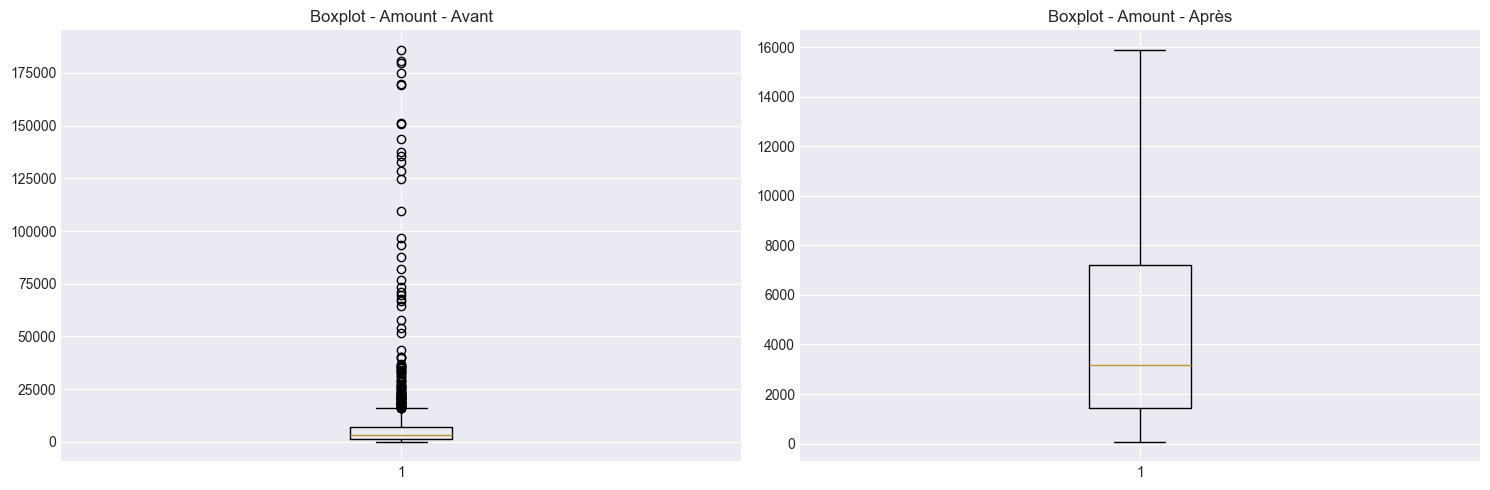

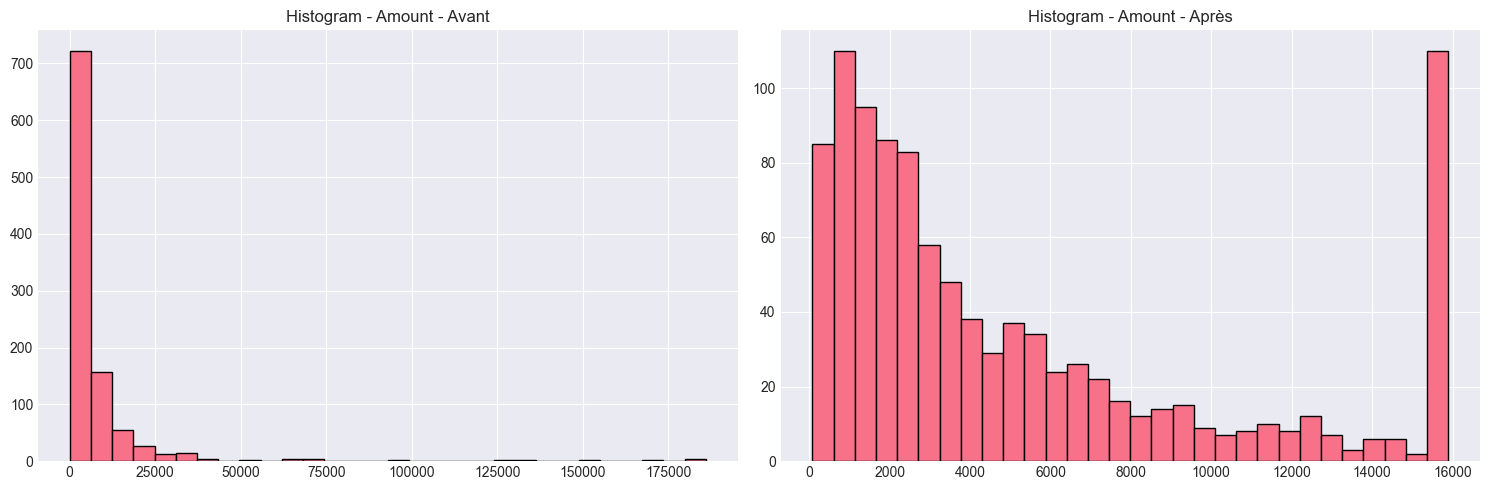

 Étape 8 complétée


In [12]:
# ========================================
# Étape 8: Visualiser la distribution avant/après traitement
# ========================================

print(f"Distribution avant traitement \n {df['amount'].describe()}")

print(f"Distribution après traitement du capping iqr \n {df_clean['amount'].describe()}")

reponse = """
On peut remarquer que :
   - la moyenne a baissé, l'écart type aussi.
   - le max a été ramené à la borne haute calculée.
   - les quartiles sont identiques.
   - la taille de l'échantillon est identique.
   # Au niveau des graphiques
   - On peut voir que les outliers du boxplot ont tous disparu
   - Sur l'histogramme, on peut voir apparaitre une grande barre sur la valeur max, ce qui est normal vu qu'on a cappé toute les valeurs supérieure a celle-ci; ce qui peut causer une abération
"""
print(reponse)

# Permet d'avoir plusieurs graphiques sur la meme ligne
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot (Graphique qui sera le premier sur l'axe)
axes[0].boxplot(df['amount'])
axes[0].set_title('Boxplot - Amount - Avant')

# Boxplot (Graphique qui sera le premier sur l'axe)
axes[1].boxplot(df_clean['amount'])
axes[1].set_title('Boxplot - Amount - Après')

plt.tight_layout()
plt.show()

# Permet d'avoir plusieurs graphiques sur la meme ligne
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram (Graphique qui sera le second sur l'axe)
axes[0].hist(df['amount'], bins=30, edgecolor='black')
axes[0].set_title('Histogram - Amount - Avant')

# Histogram (Graphique qui sera le second sur l'axe)
axes[1].hist(df_clean['amount'], bins=30, edgecolor='black')
axes[1].set_title('Histogram - Amount - Après')

plt.tight_layout()
plt.show()

# Vérification
print(f" Étape 8 complétée")

In [13]:
# ========================================
# Étape 9: Calculer l'impact sur les statistiques (moyenne, écart-type)
# ========================================

for stat in ['mean', 'std', '25%', '50%', '75%', 'min', 'max']:
    match stat:
        case 'mean':
            print(f"--- Moyenne ---")
        case 'std':
            print("--- Ecart-type ---")
        case '25%':
            print("--- Quartile 1 ---")
        case '50%':
            print("--- Quartile 2 ---")
        case '75%':
            print("--- Quartile 3 ---")
        case 'min':
            print("--- Minimum ---")
        case 'max':
            print("--- Maximum ---")
            
    print(f"Avant: {df['amount'].describe()[stat]:.2f}")
    print(f"Après : {df_clean['amount'].describe()[stat]:.2f}")
    print(f"Différence : {df['amount'].describe()[stat] - df_clean['amount'].describe()[stat]:.2f}")

# Vérification
print(f" Étape 9 complétée")

--- Moyenne ---
Avant: 8616.96
Après : 5181.40
Différence : 3435.55
--- Ecart-type ---
Avant: 20525.04
Après : 4920.61
Différence : 15604.43
--- Quartile 1 ---
Avant: 1441.20
Après : 1441.20
Différence : 0.00
--- Quartile 2 ---
Avant: 3152.76
Après : 3152.76
Différence : 0.00
--- Quartile 3 ---
Avant: 7221.39
Après : 7221.39
Différence : 0.00
--- Minimum ---
Avant: 79.57
Après : 79.57
Différence : 0.00
--- Maximum ---
Avant: 185913.06
Après : 15891.68
Différence : 170021.38
 Étape 9 complétée


In [21]:
# ========================================
# Étape 10: Documenter les outliers traités dans un rapport
# ========================================

profile = ProfileReport(df_clean, title="YData Profiling Report")
profile.to_notebook_iframe()

# Vérification
print(f" Étape 10 complétée")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:00<00:00, 147.93it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

 Étape 10 complétée


## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [15]:
transformations = ["Capping des outliers détectés via la méthode IQR"]

In [16]:
# Rapport de nettoyage
rapport = {
    'Dimensions_initiales': df.shape,
    'Dimensions_finales': df_clean.shape,  # À mettre à jour avec df_clean
    'Lignes_supprimées': df.shape[0] - df_clean.shape[0],
    'Colonnes_supprimées': df.shape[1] - df_clean.shape[1],
    'Valeurs_manquantes_traitées': df.isna().sum().sum() - df_clean.isna().sum().sum(),
    'Doublons_supprimés': df.duplicated().sum() - df_clean.duplicated().sum(),
    'Outliers_traités': len(outliers_iqr),
    'Transformations_appliquées': transformations
}

print("=" * 80)
print(" " * 25 + " RAPPORT DE NETTOYAGE")
print("=" * 80)

for key, value in rapport.items():
    print(f"{key:.<40} {value}")

print("=" * 80)
print("\n✅ TP terminé avec succès!")

                          RAPPORT DE NETTOYAGE
Dimensions_initiales.................... (1020, 4)
Dimensions_finales...................... (1020, 4)
Lignes_supprimées....................... 0
Colonnes_supprimées..................... 0
Valeurs_manquantes_traitées............. 0
Doublons_supprimés...................... 0
Outliers_traités........................ 105
Transformations_appliquées.............. ['Capping des outliers détectés via la méthode IQR']

✅ TP terminé avec succès!
